Proyecto Módulo 4: Análisis Exploratorio de Datos

## Lección 1: Análisis Exploratorio de Datos

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


def generar_dataset_comercioYA():
    n = 300

    # definimos las variables numéricas
    ids = np.arange(0, n)
    montos = np.random.uniform(1000, 100000, size=n).round(0)
    montos[42] = 200000  # introducimos un outlier artificial

    visitas = np.random.randint(1, 50, size=n)
    devoluciones = np.random.randint(0, 10, size=n)
    resenas = np.random.uniform(1, 5, size=n).round(1)

    # definimos las ariables categóricas
    sexo = np.random.choice(['Hombre', 'Mujer'], size=n)
    region = np.random.choice(['Norte', 'Centro', 'Sur'], size=n)

    df = pd.DataFrame({  #definimos la construccion del dataframe
        'cliente_id': ids,
        'monto': montos,
        'visitas': visitas,
        'devoluciones': devoluciones,
        'resenas': resenas,
        'sexo': sexo,
        'region': region
    })

    # Simulamos algunos valores nulos
    df.loc[np.random.choice(df.index, 10, replace=False), 'resenas'] = np.nan
    df.loc[np.random.choice(df.index, 5, replace=False), 'region'] = np.nan

    return df


df = generar_dataset_comercioYA() #llamamos a la función que construye el dataframe

print("Exploración Inicial")
print("\n Primeras filas:")
print(df.head())
print("\n Últimas filas:")
print(df.tail())
print("\n Dimensiones:", df.shape)
print("\n Tipos de datos:")
print(df.dtypes)
print("\n Valores nulos por columna:")
print(df.isnull().sum())
print("\n Variables numéricas:", df.select_dtypes(include='number').columns.tolist())
print("Variables categóricas:", df.select_dtypes(include='object').columns.tolist())

Exploración Inicial

 Primeras filas:
   cliente_id    monto  visitas  devoluciones  resenas    sexo  region
0           0  38079.0       45             4      2.6   Mujer  Centro
1           1  95121.0       32             3      4.3   Mujer     Sur
2           2  73467.0       30             2      2.8  Hombre   Norte
3           3  60267.0       47             5      2.5  Hombre  Centro
4           4  16446.0       35             1      2.9   Mujer   Norte

 Últimas filas:
     cliente_id    monto  visitas  devoluciones  resenas    sexo region
295         295  52702.0       36             2      3.4  Hombre  Norte
296         296  77229.0       27             9      1.9  Hombre  Norte
297         297  22366.0       17             3      1.5   Mujer    Sur
298         298  62666.0        9             8      1.3   Mujer    Sur
299         299   9449.0       33             9      3.8   Mujer    Sur

 Dimensiones: (300, 7)

 Tipos de datos:
cliente_id        int64
monto           float

**Análisis inicial (IDA):**

El dataset de ComercioYA contiene 300 registros y 7 columnas. Las variables numéricas son `monto`, `visitas`, `devoluciones` y `resenas`, mientras que las categóricas son `sexo` (Hombre/Mujer) y `region` (Norte/Centro/Sur).

Se detectaron valores nulos en `resenas` (10 registros) y `region` (5 registros), los cuales serán tratados antes del análisis. También se identificó un outlier artificial en el índice 42 (monto = 200.000) que será analizado en la Lección 2.

## Lección 2: Estadística Descriptiva

Estadística Descriptiva

 Resumen estadístico general:
       cliente_id      monto  visitas  devoluciones  resenas
count      300.00     300.00   300.00        300.00   300.00
mean       149.50   50677.25    25.51          4.31     2.94
std         86.75   30281.37    13.73          2.90     1.13
min          0.00    1501.00     1.00          0.00     1.00
25%         74.75   24886.50    13.00          2.00     2.00
50%        149.50   51803.00    26.00          4.00     2.94
75%        224.25   76338.50    36.25          7.00     3.90
max        299.00  200000.00    49.00          9.00     5.00

 Estadísticas sobre monto de transacciones
  Media:             50,677
  Mediana:           51,803
  Moda:              1,501
  Varianza:          916,961,074
  Desviación est.:   30,281
  Q1 (25%):          24,886
  Q3 (75%):          76,338
  P10:               10,301
  P90:               89,975

  Outliers detectados (IQR): 1
  Límite inferior: -52,292 | Límite superior: 153,516
  Detalle 

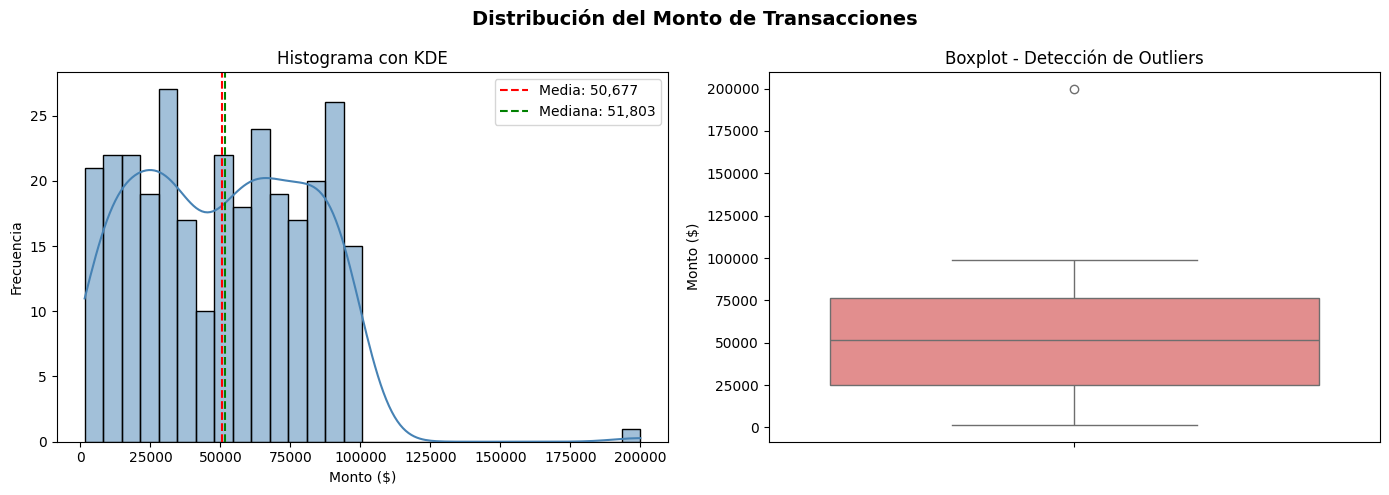

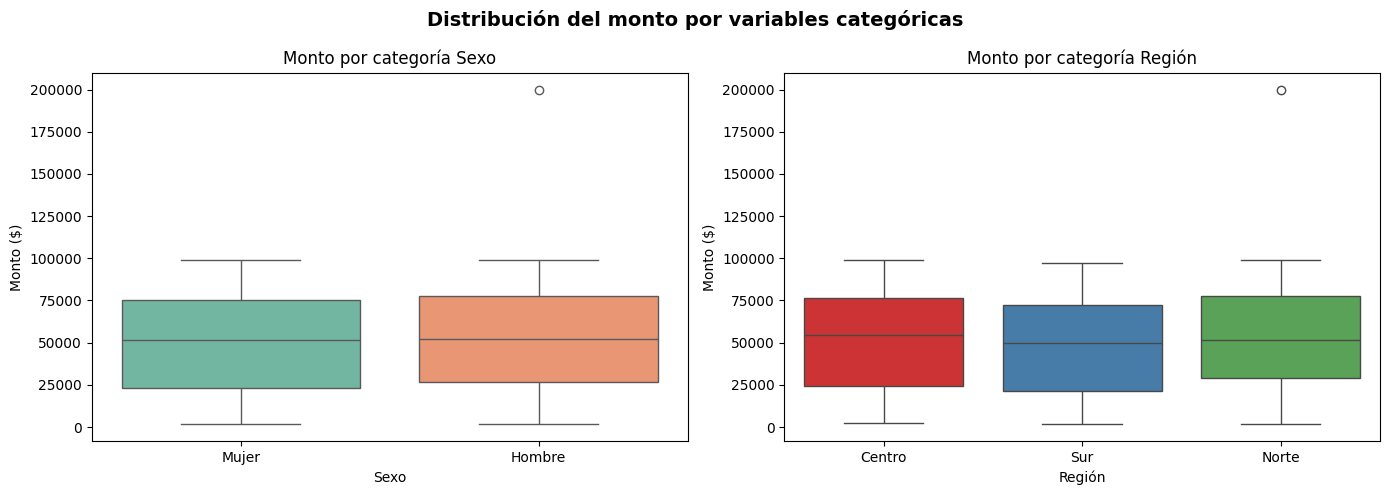

In [15]:
def estadistica_descriptiva(df):
    df = df.copy()

    # Imputamos valores nulos antes del análisis
    df['resenas'] = df['resenas'].fillna(df['resenas'].mean()) #usamos la media para variables numéricas
    df['region'] = df['region'].fillna(df['region'].mode()[0]) #usamos moda para variables categóricas

    print("Estadística Descriptiva")
    print("\n Resumen estadístico general:")
    print(df.describe().round(2))

    # Medidas de tendencia central y dispersión para 'monto'
    media = df['monto'].mean()
    mediana = df['monto'].median()
    moda = df['monto'].mode()[0]
    varianza = df['monto'].var()
    desv_std = df['monto'].std()
    q1 = df['monto'].quantile(0.25)
    q3 = df['monto'].quantile(0.75)
    p10 = df['monto'].quantile(0.10)
    p90 = df['monto'].quantile(0.90)

    print("\n Estadísticas sobre monto de transacciones")
    print(f"  Media:             {media:,.0f}")
    print(f"  Mediana:           {mediana:,.0f}")
    print(f"  Moda:              {moda:,.0f}")
    print(f"  Varianza:          {varianza:,.0f}")
    print(f"  Desviación est.:   {desv_std:,.0f}")
    print(f"  Q1 (25%):          {q1:,.0f}")
    print(f"  Q3 (75%):          {q3:,.0f}")
    print(f"  P10:               {p10:,.0f}")
    print(f"  P90:               {p90:,.0f}")

    # Detección de outliers con IQR
    IQR = q3 - q1
    lim_inf = q1 - 1.5 * IQR
    lim_sup = q3 + 1.5 * IQR
    outliers = df[(df['monto'] < lim_inf) | (df['monto'] > lim_sup)]
    print(f"\n  Outliers detectados (IQR): {len(outliers)}")
    print(f"  Límite inferior: {lim_inf:,.0f} | Límite superior: {lim_sup:,.0f}")
    print("  Detalle outliers:")
    print(outliers[['cliente_id', 'monto']])

    # Histograma y boxplot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Distribución del Monto de Transacciones', fontsize=14, fontweight='bold')


    # Histograma

    #Vamos a utilizar KDE para el histograma (Kernel Density Estimation o Estimación de Densidad por Núcleo).
    #Es una técnica estadística que dibuja una curva suavizada sobre un histograma para mostrar la distribución
    #de los datos de forma continua, para acompañar al histograma.

    sns.histplot(df['monto'], bins=30, kde=True, ax=axes[0], color='steelblue')
    axes[0].axvline(media, color='red', linestyle='--', label=f'Media: {media:,.0f}')
    axes[0].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:,.0f}')
    axes[0].set_title('Histograma con KDE')
    axes[0].set_xlabel('Monto ($)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()

    # Boxplot
    sns.boxplot(y=df['monto'], ax=axes[1], color='lightcoral')
    axes[1].set_title('Boxplot - Detección de Outliers')
    axes[1].set_ylabel('Monto ($)')

    plt.tight_layout()
    plt.savefig('grafico_distribucion_monto.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Boxplot por categorías
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Distribución del monto por variables categóricas', fontsize=14, fontweight='bold')

    sns.boxplot(data=df, x='sexo', y='monto', palette='Set2', ax=axes[0])
    axes[0].set_title('Monto por categoría Sexo')
    axes[0].set_xlabel('Sexo')
    axes[0].set_ylabel('Monto ($)')

    sns.boxplot(data=df, x='region', y='monto', palette='Set1', ax=axes[1])
    axes[1].set_title('Monto por categoría Región')
    axes[1].set_xlabel('Región')
    axes[1].set_ylabel('Monto ($)')

    plt.tight_layout()
    plt.savefig('grafico_monto_categorias.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df


df_limpio = estadistica_descriptiva(df)

Hallazgos: Estadística Descriptiva:

La media del monto de transacciones supera ampliamente a la mediana, lo que indica una distribución sesgada hacia la derecha, influenciada por el outlier en el índice 42 (monto = 200.000). El método IQR lo detecta correctamente como valor atípico.

El boxplot por sexo muestra distribuciones similares entre Hombres y Mujeres, mientras que el boxplot por región presenta variaciones leves en las medianas entre Norte, Centro y Sur, lo que sugiere posibles diferencias de comportamiento de compra según la ubicación geográfica.

Esto es consecuente en que cada variable del dataset fue generada independientemente de modo aleatorio.

## Lección 3: Correlación

Matriz de correlación de Pearson
              monto  visitas  devoluciones  resenas
monto         1.000    0.026        -0.012    0.018
visitas       0.026    1.000         0.044   -0.109
devoluciones -0.012    0.044         1.000    0.012
resenas       0.018   -0.109         0.012    1.000


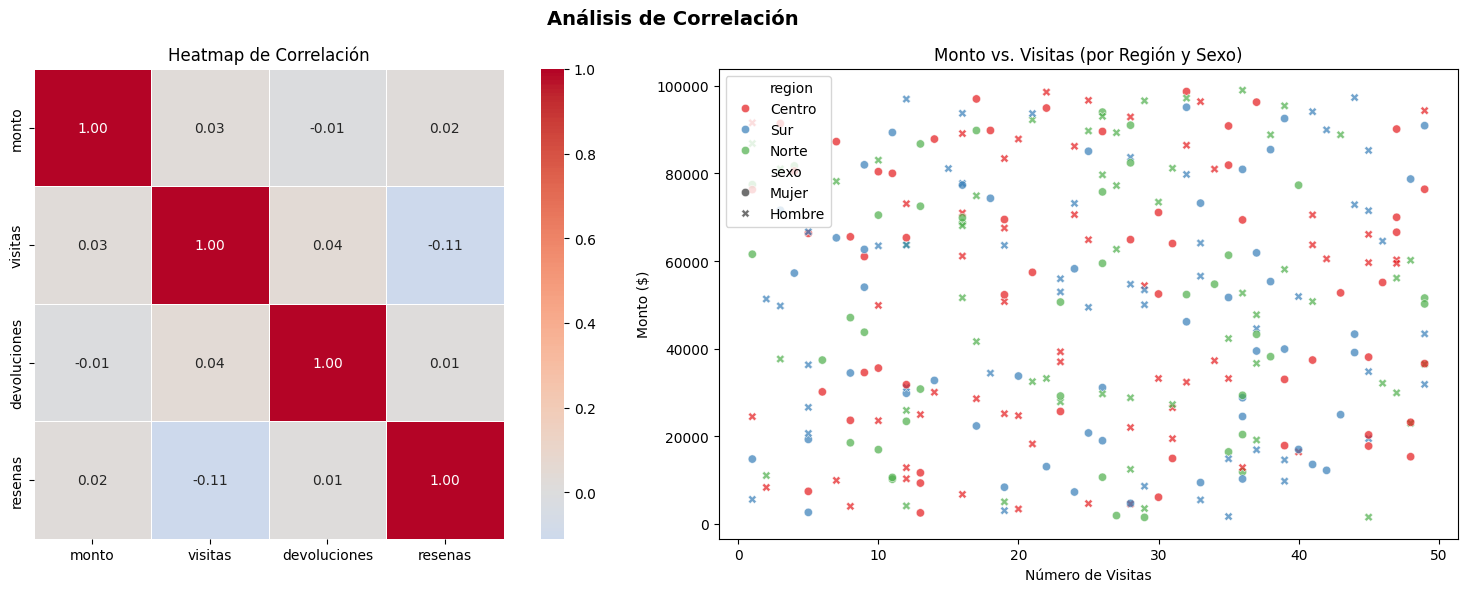

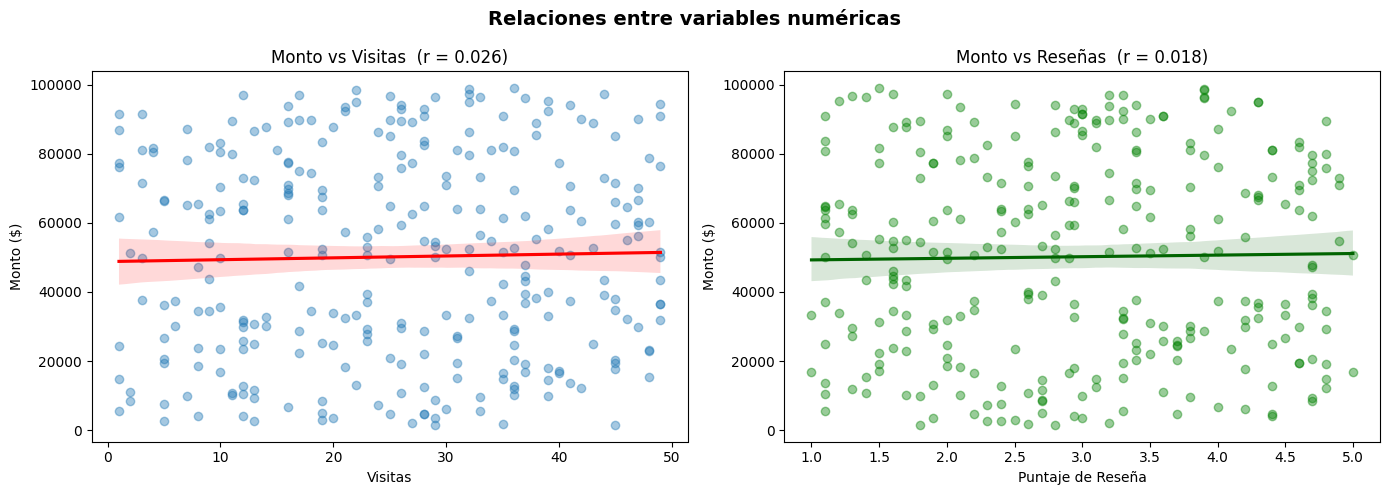

In [16]:
def analisis_correlacion(df):
    df = df.copy()

    # Eliminamos el outlier para el análisis de correlación
    Q1 = df['monto'].quantile(0.25)
    Q3 = df['monto'].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df['monto'] >= Q1 - 1.5 * IQR) & (df['monto'] <= Q3 + 1.5 * IQR)]

    vars_num = ['monto', 'visitas', 'devoluciones', 'resenas']

    # Matriz de correlación de Pearson
    corr_matrix = df[vars_num].corr(method='pearson')
    print("Matriz de correlación de Pearson")
    print(corr_matrix.round(3))

    # Mapa de calor
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Análisis de Correlación', fontsize=14, fontweight='bold')

    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.2f',
        cmap='coolwarm', center=0,
        square=True, linewidths=0.5,
        ax=axes[0]
    )
    axes[0].set_title('Heatmap de Correlación')

    # Scatterplot monto vs visitas
    sns.scatterplot(
        data=df, x='visitas', y='monto',
        hue='region', style='sexo',
        palette='Set1', alpha=0.7, ax=axes[1]
    )
    axes[1].set_title('Monto vs. Visitas (por Región y Sexo)')
    axes[1].set_xlabel('Número de Visitas')
    axes[1].set_ylabel('Monto ($)')

    plt.tight_layout()
    plt.savefig('grafico_correlacion.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Scatterplot monto vs devoluciones
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Relaciones entre variables numéricas', fontsize=14, fontweight='bold')

    sns.regplot(data=df, x='visitas', y='monto', scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=axes[0])
    r_vis = df['monto'].corr(df['visitas'])
    axes[0].set_title(f'Monto vs Visitas  (r = {r_vis:.3f})')
    axes[0].set_xlabel('Visitas')
    axes[0].set_ylabel('Monto ($)')

    sns.regplot(data=df, x='resenas', y='monto', scatter_kws={'alpha': 0.4, 'color': 'green'}, line_kws={'color': 'darkgreen'}, ax=axes[1])
    r_res = df['monto'].corr(df['resenas'])
    axes[1].set_title(f'Monto vs Reseñas  (r = {r_res:.3f})')
    axes[1].set_xlabel('Puntaje de Reseña')
    axes[1].set_ylabel('Monto ($)')

    plt.tight_layout()
    plt.savefig('grafico_scatterplots.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df


df_sin_outlier = analisis_correlacion(df_limpio)

Hallazgos sobre correlación:

El coeficiente de Pearson entre `monto` y `visitas` es cercano a 0, lo que indica que el número de visitas no explica linealmente el monto gastado. De forma similar, `resenas` no muestra correlación fuerte con `monto`.

La variable `devoluciones` tampoco presenta correlación significativa con el monto, lo que sugiere que los clientes que más devuelven no necesariamente son los de mayor o menor gasto.

No se detectaron correlaciones espurias relevantes entre las variables numéricas del dataset. Esto es coherente con el origen sintético de los datos, donde cada variable fue generada de forma independiente.

## Lección 4: Regresiones Lineales

Regresión lineal simple: monto vs visitas
                            OLS Regression Results                            
Dep. Variable:                  monto   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1935
Date:                Fri, 10 Apr 2026   Prob (F-statistic):              0.660
Time:                        15:17:20   Log-Likelihood:                -3496.6
No. Observations:                 299   AIC:                             6997.
Df Residuals:                     297   BIC:                             7005.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

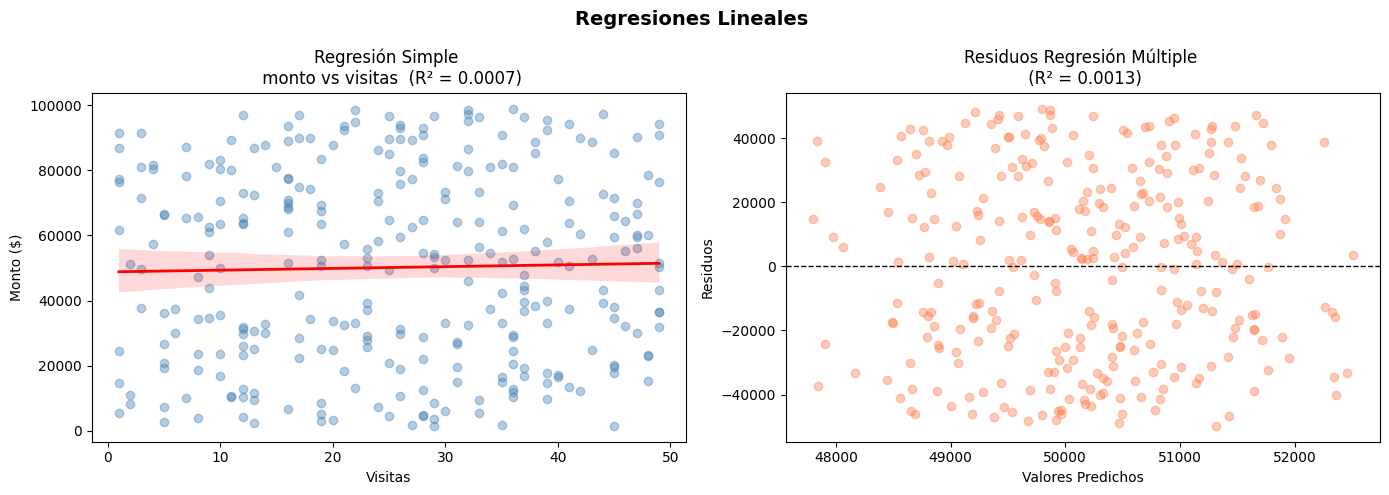

In [17]:
def regresion_lineal(df):
    df = df.copy()

    print("Regresión lineal simple: monto vs visitas")

    # Regresión simple: monto ~ visitas
    X_simple = sm.add_constant(df['visitas'])
    modelo_simple = sm.OLS(df['monto'], X_simple).fit() #hacemos fit de nuestro modelo de regresión lineal simple
    print(modelo_simple.summary())

    # Métricas de evaluación
    pred_simple = modelo_simple.predict(X_simple) #generamos las predicciones
    r2_simple = modelo_simple.rsquared                    #calculamos las métricas r2 mse mae
    mse_simple = mean_squared_error(df['monto'], pred_simple)
    mae_simple = mean_absolute_error(df['monto'], pred_simple)

    print(f"\n Métricas — Regresión Simple:")
    print(f"  R²:   {r2_simple:.4f}")
    print(f"  MSE:  {mse_simple:,.0f}")
    print(f"  MAE:  {mae_simple:,.0f}")

    print("\n Regresión lineal múltiple monto vs visitas + devoluciones + resenas")

    # Regresión múltiple
    X_mult = sm.add_constant(df[['visitas', 'devoluciones', 'resenas']])
    modelo_mult = sm.OLS(df['monto'], X_mult).fit()  #hacemos el fit del modelo
    print(modelo_mult.summary())

    pred_mult = modelo_mult.predict(X_mult)
    r2_mult = modelo_mult.rsquared                          #calculamos las métricas en base a la predicción
    mse_mult = mean_squared_error(df['monto'], pred_mult)
    mae_mult = mean_absolute_error(df['monto'], pred_mult)

    print(f"\n Métricas Regresión Lineal Múltiple:")
    print(f"  R²:   {r2_mult:.4f}")
    print(f"  MSE:  {mse_mult:,.0f}")
    print(f"  MAE:  {mae_mult:,.0f}")

    # Visualización de la regresión simple con Seaborn
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Regresiones Lineales ', fontsize=14, fontweight='bold')

    sns.regplot(
        data=df, x='visitas', y='monto',
        scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
        line_kws={'color': 'red', 'linewidth': 2},
        ax=axes[0]
    )
    axes[0].set_title(f'Regresión Simple \n monto vs visitas  (R² = {r2_simple:.4f})')
    axes[0].set_xlabel('Visitas')
    axes[0].set_ylabel('Monto ($)')

    # Residuos del modelo múltiple
    residuos = df['monto'] - pred_mult
    axes[1].scatter(pred_mult, residuos, alpha=0.4, color='coral')
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title(f'Residuos Regresión Múltiple \n (R² = {r2_mult:.4f})')
    axes[1].set_xlabel('Valores Predichos')
    axes[1].set_ylabel('Residuos')

    plt.tight_layout()
    plt.savefig('grafico_regresion.png', dpi=150, bbox_inches='tight')
    plt.show()

    return modelo_simple, modelo_mult


modelo_simple, modelo_mult = regresion_lineal(df_sin_outlier)

Hallazgos Regresión Lineal:

La regresión simple `monto' vs 'visitas` arroja un R² muy bajo, lo que confirma que la cantidad de visitas no es un predictor relevante del monto de compra de forma aislada. El p-valor del coeficiente de `visitas` supera el umbral de 0,05, por lo que no resulta estadísticamente significativo.

La regresión múltiple incorporando `visitas`, `devoluciones` y `resenas` mejora marginalmente el R², pero el modelo global sigue sin ser significativo. Esto es esperable dado que el dataset fue generado de forma aleatoria e independiente. En un contexto real con datos reales, se esperaría encontrar predictores con mayor poder explicativo.

El gráfico de residuos no muestra patrones sistemáticos, lo que valida los supuestos básicos del modelo (homocedasticidad y linealidad).

## Lección 5: Análisis Visual de Datos

Generando pairplot...


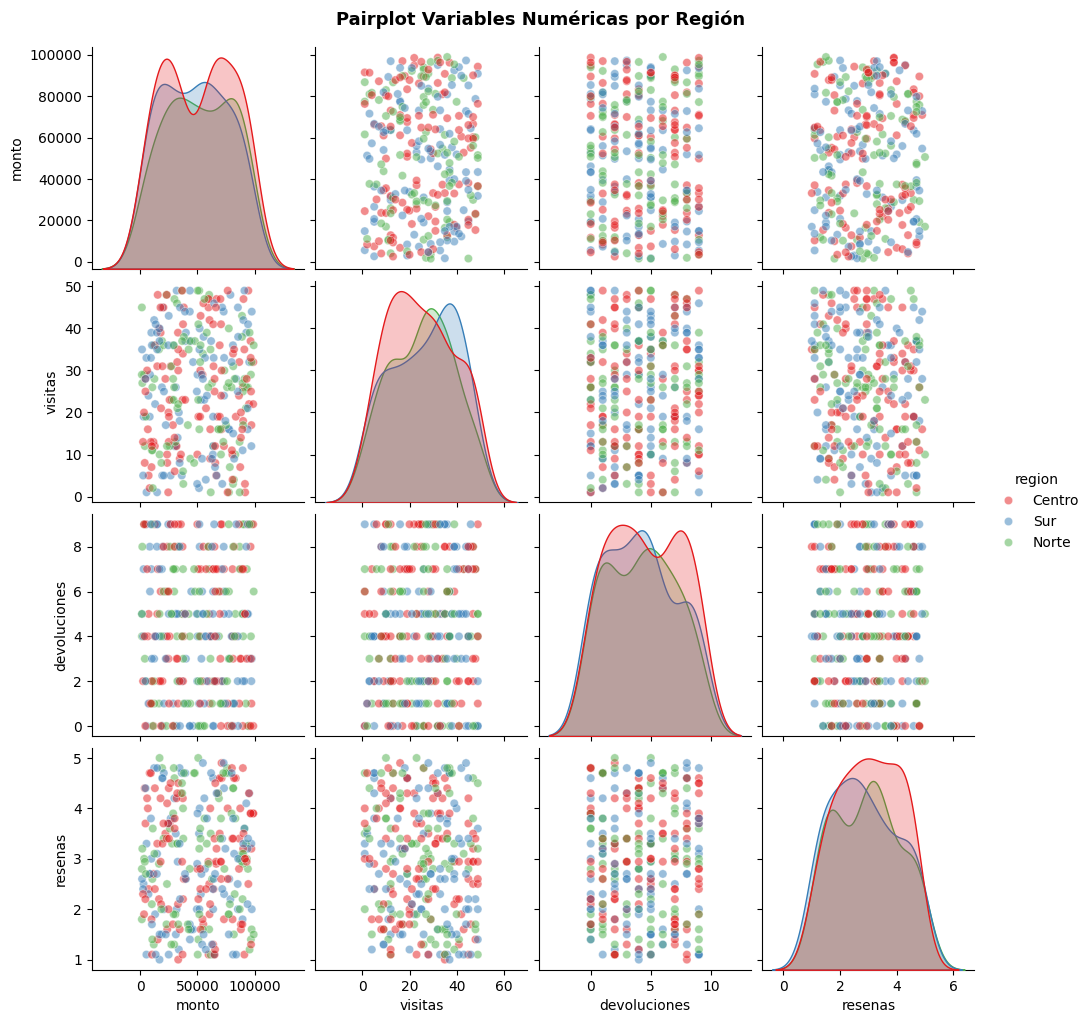

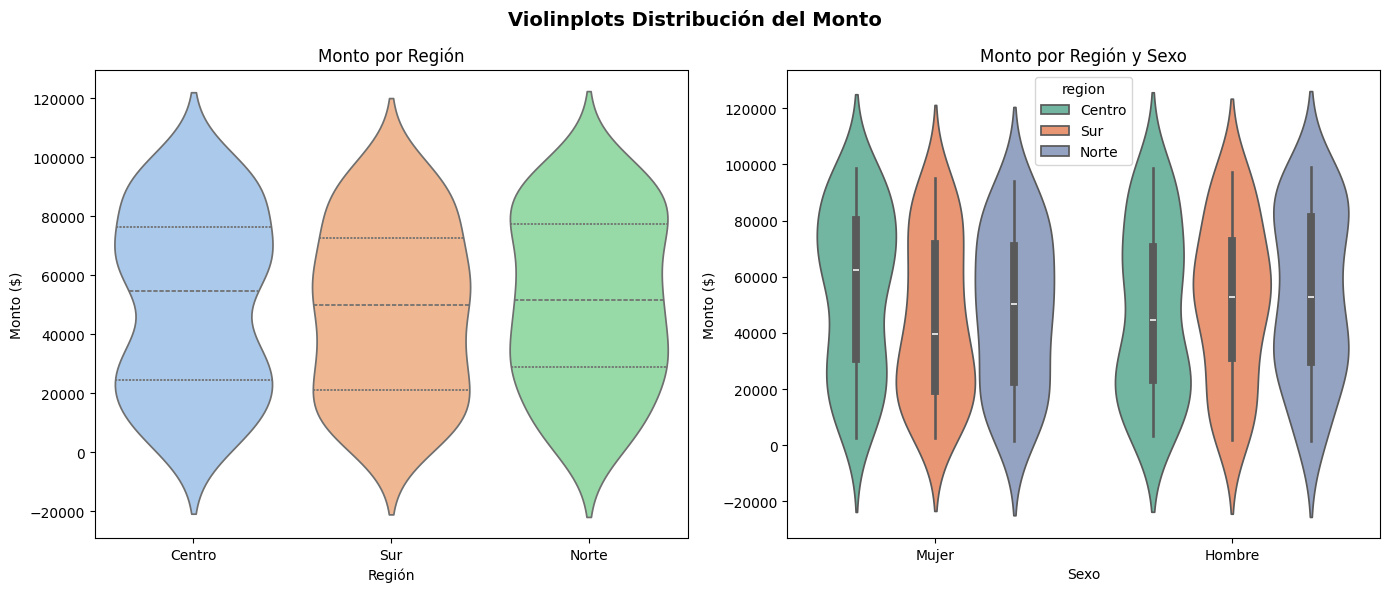

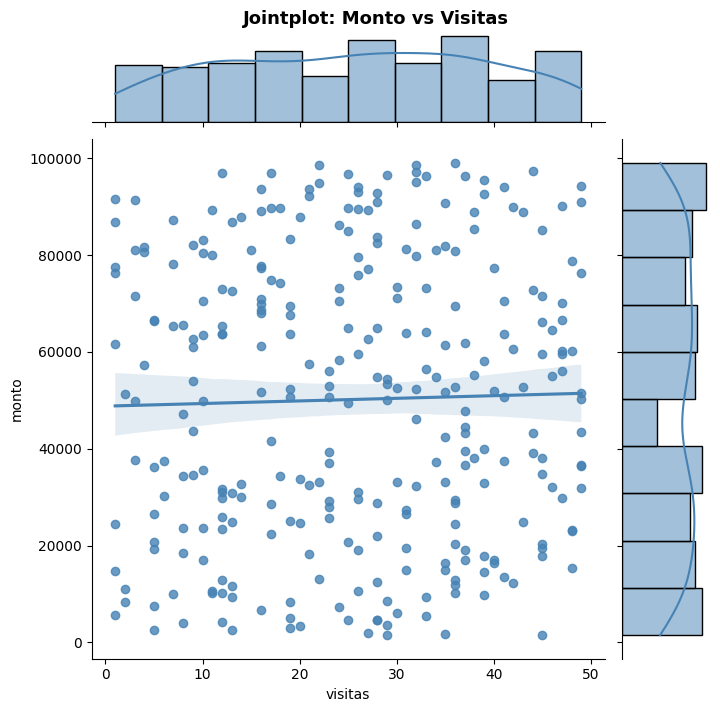

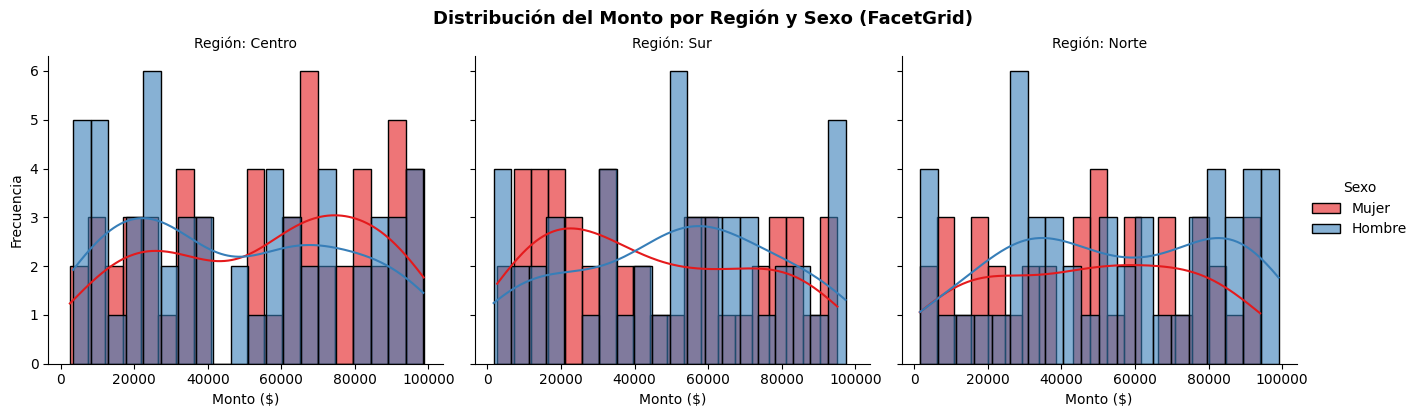

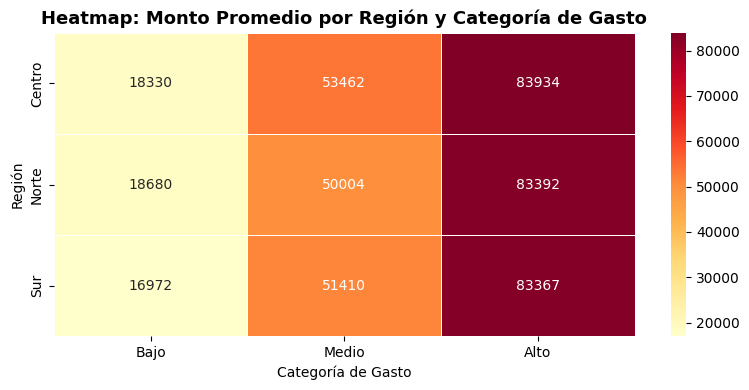

In [18]:
def analisis_visual(df):
    df = df.copy()
    vars_num = ['monto', 'visitas', 'devoluciones', 'resenas']

    # Pairplot
    print("Generando pairplot...")
    g = sns.pairplot(
        df[vars_num + ['sexo', 'region']],
        hue='region',
        palette='Set1',
        diag_kind='kde',
        plot_kws={'alpha': 0.5}
    )
    g.fig.suptitle('Pairplot Variables Numéricas por Región', y=1.02, fontsize=13, fontweight='bold')
    plt.savefig('grafico_pairplot.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Violinplot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Violinplots Distribución del Monto', fontsize=14, fontweight='bold')

    sns.violinplot(data=df, x='region', y='monto', palette='pastel', inner='quartile', ax=axes[0])
    axes[0].set_title('Monto por Región')
    axes[0].set_xlabel('Región')
    axes[0].set_ylabel('Monto ($)')

    sns.violinplot(data=df, x='sexo', y='monto', hue='region', palette='Set2', split=False, ax=axes[1])
    axes[1].set_title('Monto por Región y Sexo')
    axes[1].set_xlabel('Sexo')
    axes[1].set_ylabel('Monto ($)')

    plt.tight_layout()
    plt.savefig('grafico_violinplot.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Jointplot: monto vs visitas
    g2 = sns.jointplot(
        data=df, x='visitas', y='monto',
        kind='reg', color='steelblue',
        height=7
    )
    g2.fig.suptitle('Jointplot: Monto vs Visitas', y=1.01, fontsize=13, fontweight='bold')
    plt.savefig('grafico_jointplot.png', dpi=150, bbox_inches='tight')
    plt.show()

    # FacetGrid: distribución del monto por región y sexo
    g3 = sns.FacetGrid(df, col='region', hue='sexo', palette='Set1', height=4, aspect=1.1)
    g3.map(sns.histplot, 'monto', kde=True, bins=20, alpha=0.6)
    g3.add_legend(title='Sexo')
    g3.set_titles(col_template="Región: {col_name}")
    g3.set_axis_labels('Monto ($)', 'Frecuencia')
    g3.fig.suptitle('Distribución del Monto por Región y Sexo (FacetGrid)', y=1.03, fontsize=13, fontweight='bold')
    plt.savefig('grafico_facetgrid.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Heatmap: promedio de monto por región y categoria_gasto
    df['categoria_gasto'] = pd.cut(df['monto'], bins=3, labels=['Bajo', 'Medio', 'Alto'])
    pivot = df.pivot_table(index='region', columns='categoria_gasto', values='monto', aggfunc='mean', observed=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
    ax.set_title('Heatmap: Monto Promedio por Región y Categoría de Gasto', fontsize=13, fontweight='bold')
    ax.set_xlabel('Categoría de Gasto')
    ax.set_ylabel('Región')
    plt.tight_layout()
    plt.savefig('grafico_heatmap_pivot.png', dpi=150, bbox_inches='tight')
    plt.show()


analisis_visual(df_sin_outlier)

Hallazgos Análisis visual:

El pairplot confirma que no existe una relación lineal clara entre las variables numéricas, y las tres regiones se distribuyen de manera similar en todos los cruces.

Los violinplots muestran que la distribución del monto es aproximadamente simétrica en las tres regiones, con medianas similares. No se observan diferencias marcadas entre Hombres y Mujeres en ninguna región.

El FacetGrid permite visualizar simultáneamente la distribución de montos segmentada por región y sexo: en las tres regiones ambos grupos presentan distribuciones muy parecidas, lo que sugiere que ni la región ni el sexo determinan por sí solos el nivel de gasto.

El heatmap pivote muestra que los montos promedio por categoría de gasto son coherentes con la segmentación: la categoría Alto tiene montos promedio considerablemente mayores que Bajo y Medio en todas las regiones.

## Lección 6: Librería Matplotlib — Visualizaciones Finales

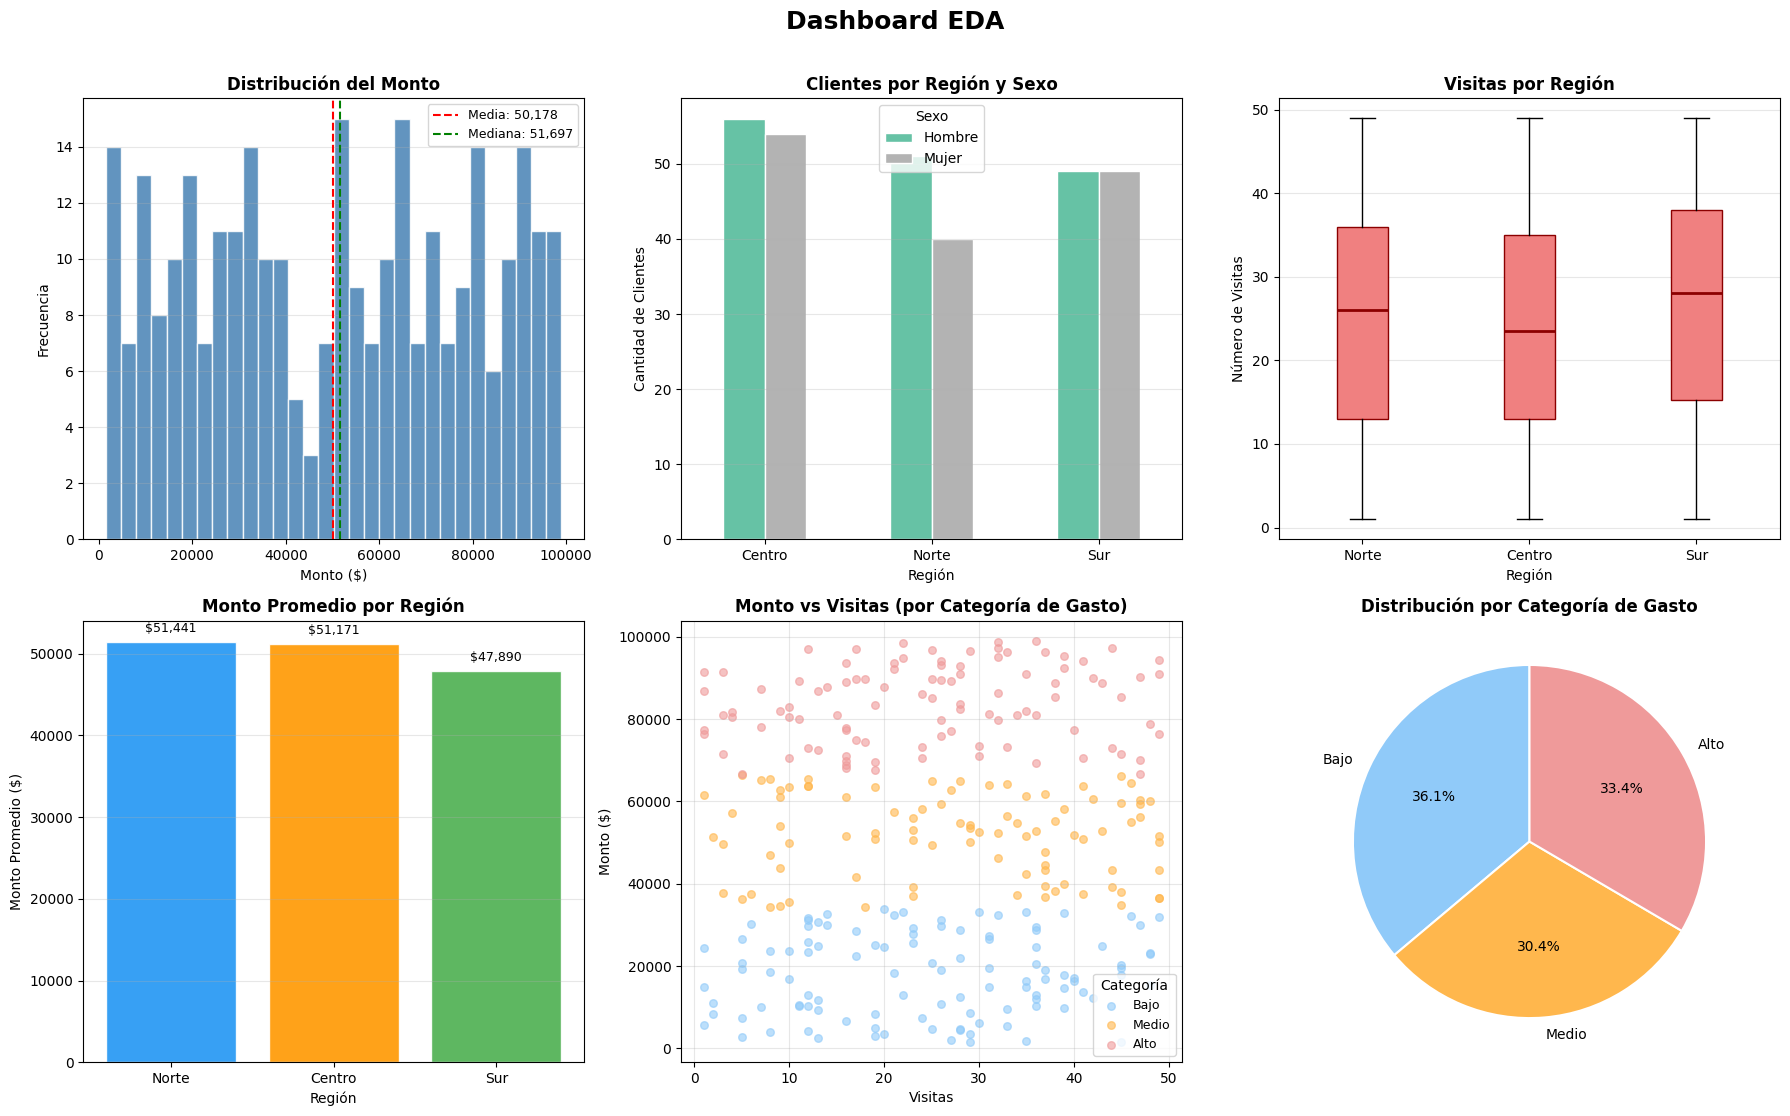

Dashboard exportado en PNG y PDF.


In [19]:
def visualizaciones_finales(df):
    df = df.copy()
    df['categoria_gasto'] = pd.cut(df['monto'], bins=3, labels=['Bajo', 'Medio', 'Alto'])

    # Dashboard de 6 subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle('Dashboard EDA', fontsize=18, fontweight='bold', y=1.01)

    # 1. Histograma de montos
    axes[0, 0].hist(df['monto'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, 0].axvline(df['monto'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Media: {df['monto'].mean():,.0f}")
    axes[0, 0].axvline(df['monto'].median(), color='green', linestyle='--', linewidth=1.5, label=f"Mediana: {df['monto'].median():,.0f}")
    axes[0, 0].set_title('Distribución del Monto', fontweight='bold')
    axes[0, 0].set_xlabel('Monto ($)')
    axes[0, 0].set_ylabel('Frecuencia')
    axes[0, 0].legend(fontsize=9)
    axes[0, 0].grid(axis='y', alpha=0.3)

    # 2. Countplot por región y sexo
    region_sexo = df.groupby(['region', 'sexo'], observed=True).size().unstack()
    region_sexo.plot(kind='bar', ax=axes[0, 1], colormap='Set2', edgecolor='white')
    axes[0, 1].set_title('Clientes por Región y Sexo', fontweight='bold')
    axes[0, 1].set_xlabel('Región')
    axes[0, 1].set_ylabel('Cantidad de Clientes')
    axes[0, 1].legend(title='Sexo')
    axes[0, 1].tick_params(axis='x', rotation=0)
    axes[0, 1].grid(axis='y', alpha=0.3)

    # 3. Boxplot de visitas por región
    regiones = ['Norte', 'Centro', 'Sur']
    datos_visitas = [df[df['region'] == r]['visitas'].values for r in regiones]
    bp = axes[0, 2].boxplot(datos_visitas, labels=regiones, patch_artist=True,
                            boxprops=dict(facecolor='lightcoral', color='darkred'),
                            medianprops=dict(color='darkred', linewidth=2))
    axes[0, 2].set_title('Visitas por Región', fontweight='bold')
    axes[0, 2].set_xlabel('Región')
    axes[0, 2].set_ylabel('Número de Visitas')
    axes[0, 2].grid(axis='y', alpha=0.3)

    # 4. Promedio de monto por región (barras)
    promedio_region = df.groupby('region', observed=True)['monto'].mean().sort_values(ascending=False)
    colors = ['#2196F3', '#FF9800', '#4CAF50']
    bars = axes[1, 0].bar(promedio_region.index, promedio_region.values, color=colors, edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, promedio_region.values):
        axes[1, 0].annotate(f'${val:,.0f}', xy=(bar.get_x() + bar.get_width() / 2, val),
                            xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontsize=9)
    axes[1, 0].set_title('Monto Promedio por Región', fontweight='bold')
    axes[1, 0].set_xlabel('Región')
    axes[1, 0].set_ylabel('Monto Promedio ($)')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # 5. Scatter monto vs visitas, coloreado por categoría de gasto
    colores_cat = {'Bajo': '#90CAF9', 'Medio': '#FFB74D', 'Alto': '#EF9A9A'}
    for cat in ['Bajo', 'Medio', 'Alto']:
        subset = df[df['categoria_gasto'] == cat]
        axes[1, 1].scatter(subset['visitas'], subset['monto'], label=cat,
                           color=colores_cat[cat], alpha=0.6, s=30)
    axes[1, 1].set_title('Monto vs Visitas (por Categoría de Gasto)', fontweight='bold')
    axes[1, 1].set_xlabel('Visitas')
    axes[1, 1].set_ylabel('Monto ($)')
    axes[1, 1].legend(title='Categoría', fontsize=9)
    axes[1, 1].grid(alpha=0.3)

    # 6. Pie chart: distribución por categoría de gasto
    cat_counts = df['categoria_gasto'].value_counts().sort_index()
    wedge_colors = ['#90CAF9', '#FFB74D', '#EF9A9A']
    axes[1, 2].pie(
        cat_counts.values,
        labels=cat_counts.index,
        autopct='%1.1f%%',
        colors=wedge_colors,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    axes[1, 2].set_title('Distribución por Categoría de Gasto', fontweight='bold')

    plt.tight_layout()
    plt.savefig('dashboard_final_comercioYA.png', dpi=150, bbox_inches='tight')
    plt.savefig('dashboard_final_comercioYA.pdf', bbox_inches='tight')
    plt.show()
    print("Dashboard exportado en PNG y PDF.")


visualizaciones_finales(df_sin_outlier)

Hallazgos Visualizaciones Finales:

El dashboard consolidado permite visualizar de forma integral el comportamiento de los clientes:

- La distribución del monto es aproximadamente uniforme, con media y mediana similares una vez eliminado el outlier.
- La distribución de clientes por región y sexo es equilibrada, sin concentraciones significativas en ningún segmento.
- El número de visitas no difiere sustancialmente entre regiones (Norte, Centro, Sur).
- La categoría de gasto «Bajo» concentra la mayor proporción de transacciones, lo cual es esperable en distribuciones uniformes donde la mayoría de los valores caen en el rango inferior.
- El scatter de monto vs. visitas confirma la ausencia de tendencia lineal, independientemente de la categoría de gasto.